# RML guide (unified)

This notebook shows how to use the new `RML.py` in three scenarios:
1) trading actions: `-1, 0, 1`
2) recurrent binary classification with a custom loss
3) quasi-continuous actions (SCF-like) on synthetic data

All examples are minimal and meant as a quick-start template.


In [1]:
import numpy as np
import tensorflow as tf

from RML import ActionSpace, DecisionRule, RML, build_mlp_encoder, build_mlp_decoder, seed_everything
from demo_helpers import (
    set_plot_style,
    generate_ar1_price,
    make_features_from_price,
    generate_trend_series,
    plot_trading_actions,
    plot_trend_with_price,
    plot_confusion_matrix,
    plot_regression,
)

seed_everything(123)
np.set_printoptions(precision=3, suppress=True)
set_plot_style()


## 1) Maximising Sharpe Ratio with actions -1, 0, 1
We generate a synthetic price series with bid/ask spread and train RML to maximize a Sharpe-like reward.
The goal is to learn discrete actions {-1, 0, 1} from recent price deltas.


In [177]:
# Synthetic price series
T = 1000
rng = np.random.default_rng(0)
price, BA = generate_ar1_price(T, rng, spread=0.0004)
x = make_features_from_price(price, window=50)

action_space = ActionSpace(values=[-1.0, 0.0, 1.0])
rule = DecisionRule(action_space, mode='nearest')

enc = build_mlp_encoder(input_dim=x.shape[1], hidden=[16, 12], activation='selu')
dec = build_mlp_decoder(
    latent_dim=enc.output_shape[-1],
    action_dim=action_space.K,
    hidden=[8, 6],
    activation='selu',
    output_dim=1,
    output_activation='tanh',
)

rml = RML(enc, dec, action_space, decision_rule=rule)
rml.set_lr(0.0001)

def sharpe_like_reward(ba, out):
    # use continuous output for reward (not discretized)
    action = tf.squeeze(out['final_raw'], axis=-1)
    bid = ba[:, 0]
    ask = ba[:, 1]
    dP = (bid[1:] - bid[:-1]) / bid[:-1]
    dF = action[1:] - action[:-1]
    cost = tf.reduce_mean((ask - bid) / bid)
    ret = dP * action[:-1] - cost * tf.abs(dF)
    return tf.reduce_mean(ret) / (tf.math.reduce_std(ret) + 1e-6)


for episode in range(2000):
    step = rml.train_step(x, BA, sharpe_like_reward, initial_action=1)
    if not episode%20:
        print(f'episode: {episode} | reward:', float(step['reward']))

actions = rml.predict_actions(x, initial_action=1, as_values=True)
actions_raw = rml.recurrence_mimicking_forward(x, 1)['final_raw']
print('actions (first 10):', actions[:10].numpy().reshape(-1))


episode: 0 | reward: -0.18275617063045502
episode: 20 | reward: -0.1192539632320404
episode: 40 | reward: -0.0638042464852333
episode: 60 | reward: 0.0028751573991030455
episode: 80 | reward: 0.07271412760019302
episode: 100 | reward: 0.15065273642539978
episode: 120 | reward: 0.20919634401798248
episode: 140 | reward: 0.27981382608413696
episode: 160 | reward: 0.3351304531097412
episode: 180 | reward: 0.3886185586452484
episode: 200 | reward: 0.4264000654220581
episode: 220 | reward: 0.4606252908706665
episode: 240 | reward: 0.48281899094581604
episode: 260 | reward: 0.5052604675292969
episode: 280 | reward: 0.5212790369987488
episode: 300 | reward: 0.5325934886932373
episode: 320 | reward: 0.5476089715957642
episode: 340 | reward: 0.5623701214790344
episode: 360 | reward: 0.5790385007858276
episode: 380 | reward: 0.584794819355011
episode: 400 | reward: 0.5961674451828003
episode: 420 | reward: 0.6054808497428894
episode: 440 | reward: 0.6145111322402954
episode: 460 | reward: 0.6246

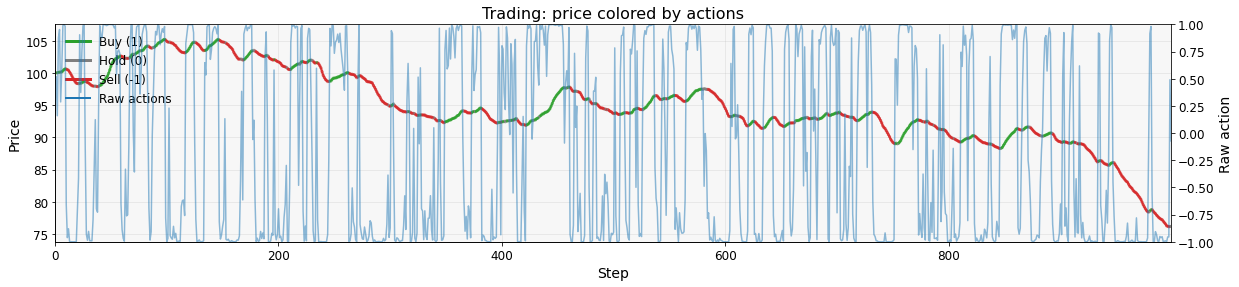

In [178]:
plot_trading_actions(price, actions, actions_raw)


## 2) Trend prediction with centered rolling labels
Synthetic time series with trend and simple outliers labels.
Labels are in {-2,-1,0,1,2}; the task is to predict them from past deltas.


In [10]:
# Synthetic trend prediction data (labels use centered rolling info)
T = 100_000
rng = np.random.default_rng(0)
price, label = generate_trend_series(T, rng)

x = make_features_from_price(price, window=100)
y = label.astype(np.int32)

action_space = ActionSpace(values=[-2.0, -1.0, 0.0, 1.0, 2.0])
rule = DecisionRule(action_space, mode='argmax')
min_action = int(action_space.values.min())

enc = build_mlp_encoder(input_dim=x.shape[1], hidden=[32, 16], activation='selu')
dec = build_mlp_decoder(
    latent_dim=enc.output_shape[-1],
    action_dim=action_space.K,
    hidden=[32, 16],
    output_dim=action_space.K,
    output_activation=None,
    activation='selu'
)

rml_cls = RML(enc, dec, action_space, decision_rule=rule)

def classification_reward(y_true, out):
    logits = out['final_raw']  # shape [T, 5]
    loss = tf.nn.sparse_softmax_cross_entropy_with_logits(
        labels=(y_true - min_action), logits=logits
    )
    return -tf.reduce_mean(loss)

for episode in range(2000):
    step = rml_cls.train_step(x, y, classification_reward, initial_action=0)
    if not episode%20:
        print('reward:', float(step['reward']))

pred = rml_cls.predict_actions(x, initial_action=0, as_values=True)
pred_np = pred.numpy().reshape(-1)
y_np = y.reshape(-1)
print('pred (first 10):', pred_np[:10])


reward: -1.8215574026107788
reward: -0.9335593581199646
reward: -0.7177450060844421
reward: -0.6226950287818909
reward: -0.572336733341217
reward: -0.5486944317817688
reward: -0.5362306833267212
reward: -0.527889609336853
reward: -0.5217965841293335
reward: -0.5164701342582703
reward: -0.5117188692092896
reward: -0.5073688626289368
reward: -0.5030090808868408
reward: -0.49891024827957153
reward: -0.4948156177997589
reward: -0.49043065309524536
reward: -0.48624202609062195
reward: -0.48263928294181824
reward: -0.4793851673603058
reward: -0.476807177066803
reward: -0.4748370349407196
reward: -0.4733075797557831
reward: -0.47189733386039734
reward: -0.47100141644477844
reward: -0.47010019421577454
reward: -0.46923336386680603
reward: -0.4684089124202728
reward: -0.4677037000656128
reward: -0.46698465943336487
reward: -0.4662635028362274
reward: -0.46574530005455017
reward: -0.46518898010253906
reward: -0.4646550714969635
reward: -0.4641003906726837
reward: -0.4636269509792328
reward: -0.4

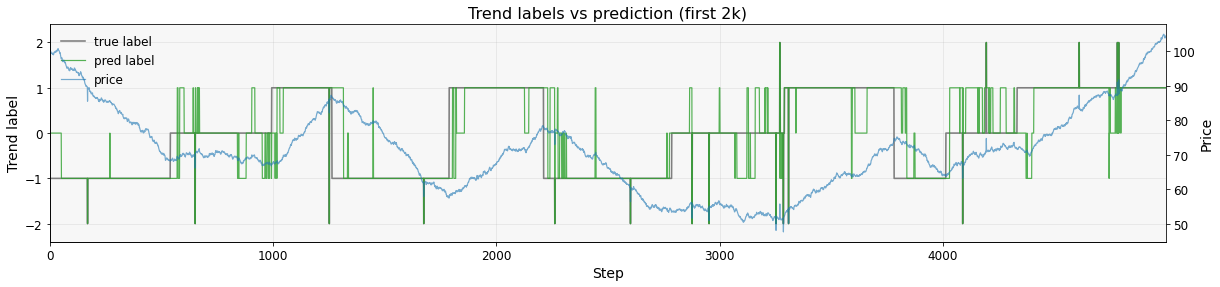

In [11]:
plot_trend_with_price(y_np, pred_np, price, n=5000)


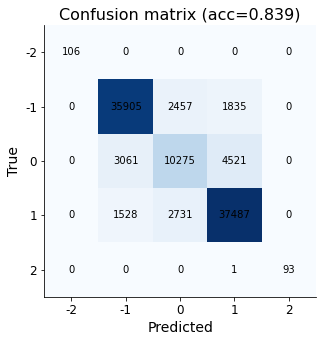

accuracy: 0.83866


In [12]:
acc = plot_confusion_matrix(y_np, pred_np, action_space.values)
print('accuracy:', acc)


## 3) Quasi-continuous actions (SCF-like)
Regression-style task with a quasi-continuous action grid; the model predicts a smooth target.


In [182]:
# Synthetic regression target
T = 250
rng = np.random.default_rng(0)
x = rng.normal(size=(T, 3)).astype(np.float32)
y = np.tanh(x[:, 0] - 0.3 * x[:, 1] + 0.2 * x[:, 2]).astype(np.float32)

grid = np.linspace(-1.0, 1.0, 11)  # quasi-continuous action set
action_space = ActionSpace(values=grid)
rule = DecisionRule(action_space, mode='nearest')
enc = build_mlp_encoder(input_dim=x.shape[1], hidden=[16, 8])
dec = build_mlp_decoder(latent_dim=enc.output_shape[-1], action_dim=action_space.K, hidden=[16], output_dim=1, output_activation='tanh')

rml_qc = RML(enc, dec, action_space, decision_rule=rule)

def quasi_continuous_reward(y_true, out):
    # Use discretized action value for reward
    y_true = tf.convert_to_tensor(y_true, dtype=tf.float32)
    pred = tf.reshape(out['final_raw'], (-1,))
    loss = tf.reduce_mean((pred - y_true) ** 2)
    return -loss

for episode in range(1000):
    step = rml_qc.train_step(x, y, quasi_continuous_reward, initial_action=0.0)
    if not episode%20:
        print('reward:', float(step['reward']))

print('reward:', float(step['reward']))
pred = rml_qc.predict_actions(x, initial_action=0.0, as_values=True)
print('pred (first 10):', pred[:10].numpy().reshape(-1))


reward: -0.5397738218307495
reward: -0.4638746976852417
reward: -0.3811420798301697
reward: -0.3022499680519104
reward: -0.18512731790542603
reward: -0.12352818250656128
reward: -0.06432298570871353
reward: -0.029719309881329536
reward: -0.015735598281025887
reward: -0.010794227942824364
reward: -0.00795151386409998
reward: -0.006554035935550928
reward: -0.0054906196892261505
reward: -0.004841409623622894
reward: -0.0040458496659994125
reward: -0.003675933228805661
reward: -0.0035996627993881702
reward: -0.0033668808173388243
reward: -0.0028956907335668802
reward: -0.0026591592468321323
reward: -0.002443592296913266
reward: -0.002248849254101515
reward: -0.0021104998886585236
reward: -0.0019525089301168919
reward: -0.0018168380483984947
reward: -0.0017012605676427484
reward: -0.0015945257619023323
reward: -0.0015002551954239607
reward: -0.001422420609742403
reward: -0.0013300988357514143
reward: -0.0012455255491659045
reward: -0.0011814277386292815
reward: -0.001117402920499444
reward:

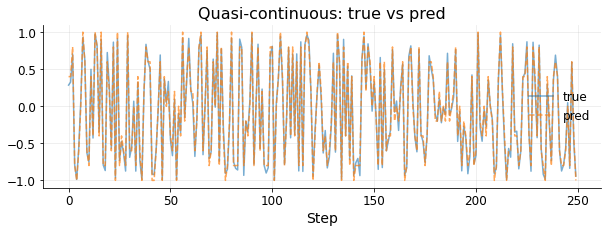

In [185]:
plot_regression(y, pred.numpy().reshape(-1), title='Quasi-continuous: true vs pred')


In [184]:
mse = float(np.mean((pred.numpy().reshape(-1) - y) ** 2))
print('mse:', mse)


mse: 0.004064842127263546


### Notes
- `ActionSpace(values=...)` defines any discrete set (including dense grids).
- `DecisionRule` controls how decoder outputs map to action indices.
- You can swap encoder/decoder with your own architectures without changing the RML core.
